In [1]:
import pandas as pd
from transformers import pipeline
import matplotlib.pyplot as plt
import time

In [3]:
data = [
    # ---- Comentarios positivos ----
    {"texto": "Excelente servicio, todo muy limpio y ordenado", "sentimiento_esperado": "POS"},
    {"texto": "El personal fue increíblemente amable", "sentimiento_esperado": "POS"},
    {"texto": "La vista desde la habitación era hermosa", "sentimiento_esperado": "POS"},
    {"texto": "Volveré sin dudarlo, me encantó el desayuno", "sentimiento_esperado": "POS"},
    {"texto": "Todo perfecto, el check-in fue rápido", "sentimiento_esperado": "POS"},
    {"texto": "Increíble atención, el personal muy servicial", "sentimiento_esperado": "POS"},
    {"texto": "Habitaciones cómodas y modernas, muy recomendable", "sentimiento_esperado": "POS"},
    {"texto": "El spa fue una experiencia relajante y maravillosa", "sentimiento_esperado": "POS"},
    {"texto": "Muy buena relación calidad-precio", "sentimiento_esperado": "POS"},
    {"texto": "Excelente experiencia, sin quejas", "sentimiento_esperado": "POS"},
    {"texto": "Todo funcionó bien, volvería otra vez", "sentimiento_esperado": "POS"},
    {"texto": "Ambiente tranquilo, ideal para descansar", "sentimiento_esperado": "POS"},
    {"texto": "Atención de primera, me hicieron sentir en casa", "sentimiento_esperado": "POS"},
    {"texto": "El restaurante tenía comida deliciosa", "sentimiento_esperado": "POS"},
    {"texto": "Personal muy atento y profesional", "sentimiento_esperado": "POS"},
    {"texto": "Definitivamente lo recomendaría a mis amigos", "sentimiento_esperado": "POS"},
    {"texto": "Todo impecable, un diez en limpieza", "sentimiento_esperado": "POS"},
    {"texto": "Me encantó la piscina, muy limpia y grande", "sentimiento_esperado": "POS"},
    {"texto": "Lugar acogedor y con buena energía", "sentimiento_esperado": "POS"},
    {"texto": "Gran experiencia, excelente atención al detalle", "sentimiento_esperado": "POS"},

    # ---- Comentarios negativos ----
    {"texto": "El baño estaba sucio y olía mal", "sentimiento_esperado": "NEG"},
    {"texto": "No me gustó el trato del recepcionista", "sentimiento_esperado": "NEG"},
    {"texto": "Demasiado ruido por las noches", "sentimiento_esperado": "NEG"},
    {"texto": "La habitación tenía cucarachas, pésimo", "sentimiento_esperado": "NEG"},
    {"texto": "La comida del restaurante fue terrible", "sentimiento_esperado": "NEG"},
    {"texto": "Nunca volvería, una experiencia horrible", "sentimiento_esperado": "NEG"},
    {"texto": "El aire acondicionado no funcionaba", "sentimiento_esperado": "NEG"},
    {"texto": "Tardaron más de una hora en darme mi habitación", "sentimiento_esperado": "NEG"},
    {"texto": "El WiFi no funcionó en ningún momento", "sentimiento_esperado": "NEG"},
    {"texto": "Demasiado caro para el servicio que ofrecen", "sentimiento_esperado": "NEG"},
    {"texto": "Mal servicio al cliente, no resolvieron mi problema", "sentimiento_esperado": "NEG"},
    {"texto": "Poca higiene en las áreas comunes", "sentimiento_esperado": "NEG"},
    {"texto": "La cama era incómoda y vieja", "sentimiento_esperado": "NEG"},
    {"texto": "No volvería, pésima experiencia", "sentimiento_esperado": "NEG"},
    {"texto": "El ascensor no funcionaba", "sentimiento_esperado": "NEG"},
    {"texto": "Atención muy lenta en recepción", "sentimiento_esperado": "NEG"},
    {"texto": "El desayuno era muy limitado", "sentimiento_esperado": "NEG"},
    {"texto": "El lugar se veía descuidado", "sentimiento_esperado": "NEG"},
    {"texto": "No vale lo que cuesta", "sentimiento_esperado": "NEG"},
    {"texto": "Me cobraron de más, mal manejo", "sentimiento_esperado": "NEG"},

    # ---- Comentarios neutros / consultas ----
    {"texto": "¿Tienen habitaciones disponibles para este fin de semana?", "sentimiento_esperado": "NEU"},
    {"texto": "¿Incluye desayuno el paquete familiar?", "sentimiento_esperado": "NEU"},
    {"texto": "Necesito saber si hay estacionamiento", "sentimiento_esperado": "NEU"},
    {"texto": "¿Aceptan mascotas pequeñas?", "sentimiento_esperado": "NEU"},
    {"texto": "Quisiera más información sobre las promociones", "sentimiento_esperado": "NEU"},
    {"texto": "¿Dónde puedo ver las tarifas actualizadas?", "sentimiento_esperado": "NEU"},
    {"texto": "¿Tienen disponibilidad para grupo de 10 personas?", "sentimiento_esperado": "NEU"},
    {"texto": "Estoy interesado en reservar para diciembre", "sentimiento_esperado": "NEU"},
    {"texto": "¿El check-in se puede hacer temprano?", "sentimiento_esperado": "NEU"},
    {"texto": "¿Puedo pagar con tarjeta Visa?", "sentimiento_esperado": "NEU"},
    {"texto": "¿El hotel cuenta con gimnasio?", "sentimiento_esperado": "NEU"},
    {"texto": "¿Cómo puedo cancelar una reserva?", "sentimiento_esperado": "NEU"},
    {"texto": "¿Tienen servicio de transporte al aeropuerto?", "sentimiento_esperado": "NEU"},
    {"texto": "¿Ofrecen habitaciones triples?", "sentimiento_esperado": "NEU"},
    {"texto": "¿Hay habitaciones con balcón?", "sentimiento_esperado": "NEU"},
    {"texto": "¿Tienen disponibilidad para la próxima semana?", "sentimiento_esperado": "NEU"},
    {"texto": "Me gustaría saber si ofrecen paquetes de luna de miel", "sentimiento_esperado": "NEU"},
    {"texto": "¿Tienen algún descuento para estadías largas?", "sentimiento_esperado": "NEU"},
    {"texto": "¿Puedo hacer una reserva por teléfono?", "sentimiento_esperado": "NEU"},
    {"texto": "¿Cuál es el horario del restaurante?", "sentimiento_esperado": "NEU"},

    # ---- Más comentarios de leads e interés ----
    {"texto": "Estoy interesado en sus servicios de hospedaje", "sentimiento_esperado": "POS"},
    {"texto": "¿Podrían enviarme más información?", "sentimiento_esperado": "NEU"},
    {"texto": "Me interesa reservar una habitación doble", "sentimiento_esperado": "POS"},
    {"texto": "Gracias por la atención, pronto haré la reserva", "sentimiento_esperado": "POS"},
    {"texto": "¿Podrían contactarme para más detalles?", "sentimiento_esperado": "NEU"},
    {"texto": "Estoy comparando opciones antes de decidir", "sentimiento_esperado": "NEU"},
    {"texto": "Parece interesante, ¿tienen fotos del lugar?", "sentimiento_esperado": "NEU"},
    {"texto": "Me interesa conocer los precios por noche", "sentimiento_esperado": "NEU"},
    {"texto": "Excelente propuesta, justo lo que buscaba", "sentimiento_esperado": "POS"},
    {"texto": "Gracias por responder tan rápido", "sentimiento_esperado": "POS"},
    {"texto": "¿Cuánto cuesta una noche en habitación simple?", "sentimiento_esperado": "NEU"},
    {"texto": "Estoy interesado, por favor envíenme información", "sentimiento_esperado": "POS"},
    {"texto": "¿Dónde están ubicados exactamente?", "sentimiento_esperado": "NEU"},
    {"texto": "Quiero hacer una reserva directamente", "sentimiento_esperado": "POS"},
    {"texto": "¿Puedo pagar al llegar al hotel?", "sentimiento_esperado": "NEU"},
    {"texto": "He escuchado buenas opiniones de este hotel", "sentimiento_esperado": "POS"},
    {"texto": "¿Hay disponibilidad para este viernes?", "sentimiento_esperado": "NEU"},
    {"texto": "Por favor envíen tarifas actualizadas", "sentimiento_esperado": "NEU"},
    {"texto": "Gran opción para vacaciones, se ve cómodo", "sentimiento_esperado": "POS"},
    {"texto": "¿Cuáles son los métodos de pago aceptados?", "sentimiento_esperado": "NEU"},
]
df = pd.DataFrame(data)
len(df)

80

In [4]:
from tqdm.notebook import tqdm
from transformers import pipeline, logging

logging.set_verbosity_info()

modelos = {
    "Robertuito": "pysentimiento/robertuito-sentiment-analysis",
    # si tuvieras más, puedes listarlos aquí
}

analyzers = {}
for nombre, modelo in tqdm(modelos.items(), desc="Cargando modelos"):
    print(f"\n→ Cargando modelo: {nombre}")
    analyzers[nombre] = pipeline("sentiment-analysis", model=modelo)


Cargando modelos:   0%|          | 0/1 [00:00<?, ?it/s]


→ Cargando modelo: Robertuito


loading configuration file config.json from cache at /home/ander/.cache/huggingface/hub/models--pysentimiento--robertuito-sentiment-analysis/snapshots/a2cc0f67ebd705c55191e25a05ba23d885fcc09b/config.json
Model config RobertaConfig {
  "architectures": [
    "RobertaForSequenceClassification"
  ],
  "attention_probs_dropout_prob": 0.1,
  "bos_token_id": 0,
  "classifier_dropout": null,
  "dtype": "float32",
  "eos_token_id": 2,
  "gradient_checkpointing": false,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "id2label": {
    "0": "NEG",
    "1": "NEU",
    "2": "POS"
  },
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "label2id": {
    "NEG": 0,
    "NEU": 1,
    "POS": 2
  },
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 130,
  "model_type": "roberta",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pad_token_id": 1,
  "position_embedding_type": "absolute",
  "problem_type": "single_label_classification",
  "transformers

In [7]:
resultados = []

for nombre, analizador in analyzers.items():
    print(f"\nEvaluando modelo: {nombre}")
    correctos = 0
    inicio = time.time()
    
    for _, fila in df.iterrows():
        pred = analizador(fila["texto"])[0]["label"]
        if pred == fila["sentimiento_esperado"]:
            correctos += 1
    
    fin = time.time()
    precision = correctos / len(df)
    tiempo_prom = (fin - inicio) / len(df)
    
    resultados.append({
        "modelo": nombre,
        "precision": round(precision, 2),
        "tiempo_promedio_seg": round(tiempo_prom, 4)
    })

pd.DataFrame(resultados)


Evaluando modelo: Robertuito


,modelo,precision,tiempo_promedio_seg
0,Robertuito,0.95,0.0059


       modelo  precision  tiempo_promedio_seg
0  Robertuito       0.95               0.0059


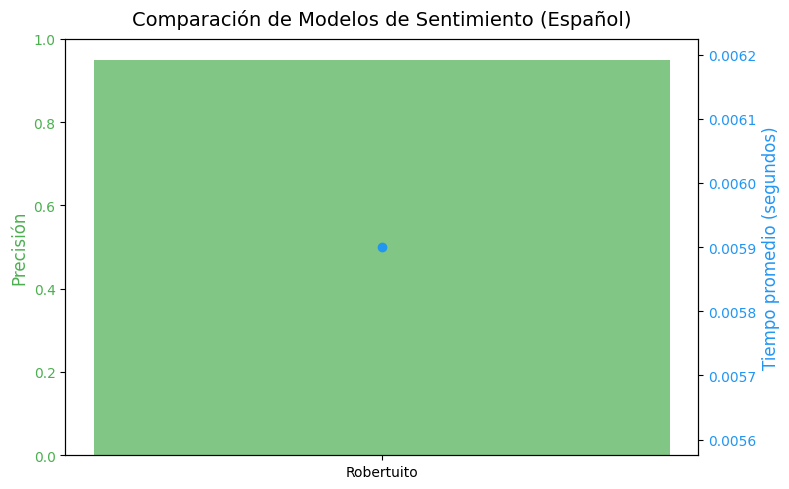

In [8]:
import matplotlib.pyplot as plt

df_resultados = pd.DataFrame(resultados)
print(df_resultados.head())


fig, ax1 = plt.subplots(figsize=(8,5))

# Eje 1: Precisión
ax1.bar(df_resultados["modelo"], df_resultados["precision"], color="#4CAF50", alpha=0.7, label="Precisión")
ax1.set_ylabel("Precisión", color="#4CAF50", fontsize=12)
ax1.set_ylim(0, 1)
ax1.tick_params(axis="y", labelcolor="#4CAF50")

# Eje 2: Tiempo promedio (segundos)
ax2 = ax1.twinx()
ax2.plot(df_resultados["modelo"], df_resultados["tiempo_promedio_seg"], color="#2196F3", marker="o", linewidth=2, label="Tiempo promedio (s)")
ax2.set_ylabel("Tiempo promedio (segundos)", color="#2196F3", fontsize=12)
ax2.tick_params(axis="y", labelcolor="#2196F3")

# Título y leyenda
plt.title("Comparación de Modelos de Sentimiento (Español)", fontsize=14, pad=10)
fig.tight_layout()
plt.show()